# Deteksi Outlier Konsentrasi Karbon Monoksida (CO) Menggunakan Metode Z-Score Bertahap

**Dataset**: `data/csv/polutan_co_bangkalan.csv` (Rentang 1 - 365 Hari)

## Tahap 1: Memuat Data dan Eksplorasi Data 1 Tahun

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

input_path = "../data/csv/polutan_co_bangkalan.csv"
if not os.path.exists(input_path):
    input_path = "data/csv/polutan_co_bangkalan.csv"

df_raw = pd.read_csv(input_path)
df = df_raw.iloc[:365].copy()
df['tanggal'] = pd.to_datetime(df['tanggal'])

print("=== PROFIL DATASET 1 TAHUN (HARI 1 - 365) ===")
print(f"Total Baris Data        : {len(df)} hari")
print(f"Rentang Tanggal         : {df['tanggal'].min().strftime('%Y-%m-%d')} s.d. {df['tanggal'].max().strftime('%Y-%m-%d')}")
print(f"Data Valid (Terisi)     : {df['CO'].notna().sum()} hari")
print(f"Missing Values (NaN)    : {df['CO'].isna().sum()} hari")
display(df.head())

=== PROFIL DATASET 1 TAHUN (HARI 1 - 365) ===
Total Baris Data        : 365 hari
Rentang Tanggal         : 2025-08-24 s.d. 2026-08-23
Data Valid (Terisi)     : 236 hari
Missing Values (NaN)    : 129 hari


,tanggal,CO
0,2025-08-24,0.032369
1,2025-08-25,0.029644
2,2025-08-26,NaN
3,2025-08-27,0.028471
4,2025-08-28,0.024230


## Tahap 2: Eksplorasi Statistik Deskriptif dan Visualisasi Awal

,Parameter,Nilai
0,Jumlah Data Valid,236
1,Rata-rata (μ),0.02882526
2,Standar Deviasi (σ),0.00318052
3,Median,0.02864418
4,Min,0.02048735
5,Max,0.04421752


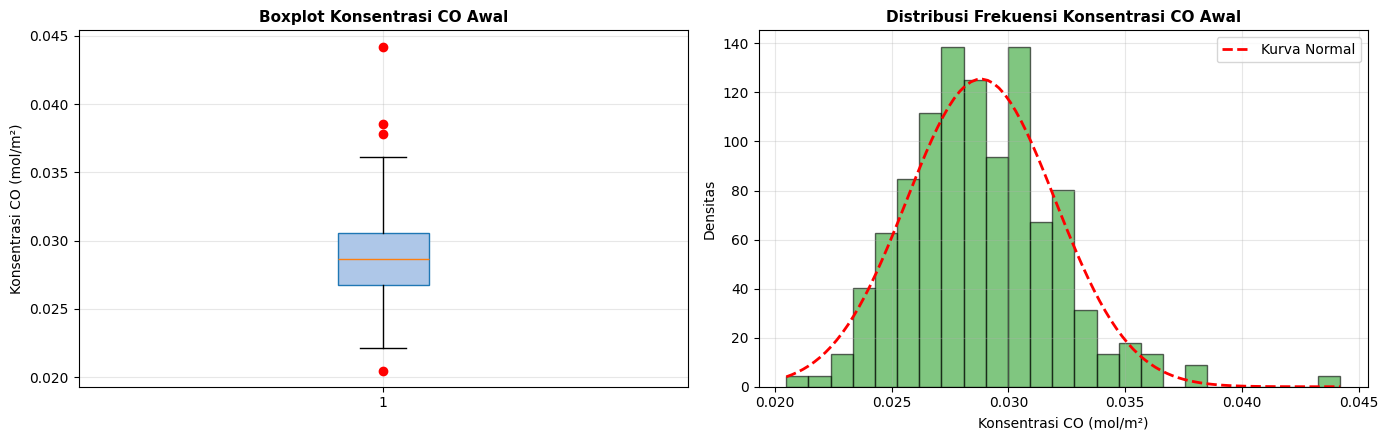

In [2]:
co_valid = df['CO'].dropna()
mean_co = co_valid.mean()
std_co = co_valid.std()

df_stat = pd.DataFrame({
    'Parameter': ['Jumlah Data Valid', 'Rata-rata (μ)', 'Standar Deviasi (σ)', 'Median', 'Min', 'Max'],
    'Nilai': [len(co_valid), f"{mean_co:.8f}", f"{std_co:.8f}", f"{co_valid.median():.8f}", f"{co_valid.min():.8f}", f"{co_valid.max():.8f}"]
})
display(df_stat)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].boxplot(co_valid, patch_artist=True, boxprops=dict(facecolor='#aec7e8', color='#1f77b4'),
                flierprops=dict(marker='o', markerfacecolor='red', markeredgecolor='red', markersize=6))
axes[0].set_title('Boxplot Konsentrasi CO Awal', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Konsentrasi CO (mol/m²)')
axes[0].grid(True, alpha=0.3)

axes[1].hist(co_valid, bins=25, density=True, alpha=0.6, color='#2ca02c', edgecolor='black')
x_pts = np.linspace(co_valid.min(), co_valid.max(), 100)
axes[1].plot(x_pts, stats.norm.pdf(x_pts, mean_co, std_co), 'r--', linewidth=2, label='Kurva Normal')
axes[1].set_title('Distribusi Frekuensi Konsentrasi CO Awal', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Konsentrasi CO (mol/m²)')
axes[1].set_ylabel('Densitas')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

## Tahap 3: Deteksi Outlier Bertahap (Iterative Z-Score |Z| > 3.0)

In [3]:
THRESHOLD = 3.0
df_iter = df.copy()
all_outliers = []
iteration = 1

print("=== MEMULAI PROSES DETEKSI Z-SCORE BERTAHAP (ITERATIVE) ===\n")
while True:
    valid_series = df_iter['CO'].dropna()
    curr_mean = valid_series.mean()
    curr_std = valid_series.std()
    curr_z = (df_iter['CO'] - curr_mean) / curr_std
    round_outliers = curr_z[curr_z.abs() > THRESHOLD]
    
    print(f"--- TAHAP {iteration} ---")
    print(f"Rata-rata (μ)        : {curr_mean:.8f}")
    print(f"Standar Deviasi (σ)  : {curr_std:.8f}")
    print(f"Outlier Ditemukan    : {len(round_outliers)} titik")
    
    if len(round_outliers) == 0:
        print(f">>> STATUS: KONVERGEN! Data 100% BEBAS DARI OUTLIER pada Tahap {iteration}.\n")
        break
        
    for idx in round_outliers.index:
        tgl = df_iter.loc[idx, 'tanggal'].strftime('%Y-%m-%d')
        val = df_iter.loc[idx, 'CO']
        z_val = curr_z.loc[idx]
        all_outliers.append({'Tahap': f'Tahap {iteration}', 'Index': idx, 'Tanggal': tgl, 'Nilai CO': val, 'Z-Score': z_val})
        print(f"  * Dihilangkan: {tgl} | CO = {val:.8f} | Z = {z_val:+.2f}")
        
    df_iter.loc[round_outliers.index, 'CO'] = np.nan
    iteration += 1

df_outliers_summary = pd.DataFrame(all_outliers)
print("=" * 65)
print(f"TOTAL OUTLIER YANG DIHILANGKAN DARI PROSES BERTAHAP: {len(df_outliers_summary)} TITIK")
print("=" * 65)
display(df_outliers_summary)

=== MEMULAI PROSES DETEKSI Z-SCORE BERTAHAP (ITERATIVE) ===

--- TAHAP 1 ---
Rata-rata (μ)        : 0.02882526
Standar Deviasi (σ)  : 0.00318052
Outlier Ditemukan    : 2 titik
  * Dihilangkan: 2025-10-07 | CO = 0.04421752 | Z = +4.84
  * Dihilangkan: 2026-07-23 | CO = 0.03851003 | Z = +3.05
--- TAHAP 2 ---
Rata-rata (μ)        : 0.02871809
Standar Deviasi (σ)  : 0.00296170
Outlier Ditemukan    : 1 titik
  * Dihilangkan: 2025-09-24 | CO = 0.03780002 | Z = +3.07
--- TAHAP 3 ---
Rata-rata (μ)        : 0.02867911
Standar Deviasi (σ)  : 0.00290730
Outlier Ditemukan    : 0 titik
>>> STATUS: KONVERGEN! Data 100% BEBAS DARI OUTLIER pada Tahap 3.

TOTAL OUTLIER YANG DIHILANGKAN DARI PROSES BERTAHAP: 3 TITIK


,Tahap,Index,Tanggal,Nilai CO,Z-Score
0,Tahap 1,44,2025-10-07,0.044218,4.839537
1,Tahap 1,333,2026-07-23,0.038510,3.045025
2,Tahap 2,31,2025-09-24,0.037800,3.066461


## Tahap 4: Visualisasi Hasil Deteksi Outlier Bertahap

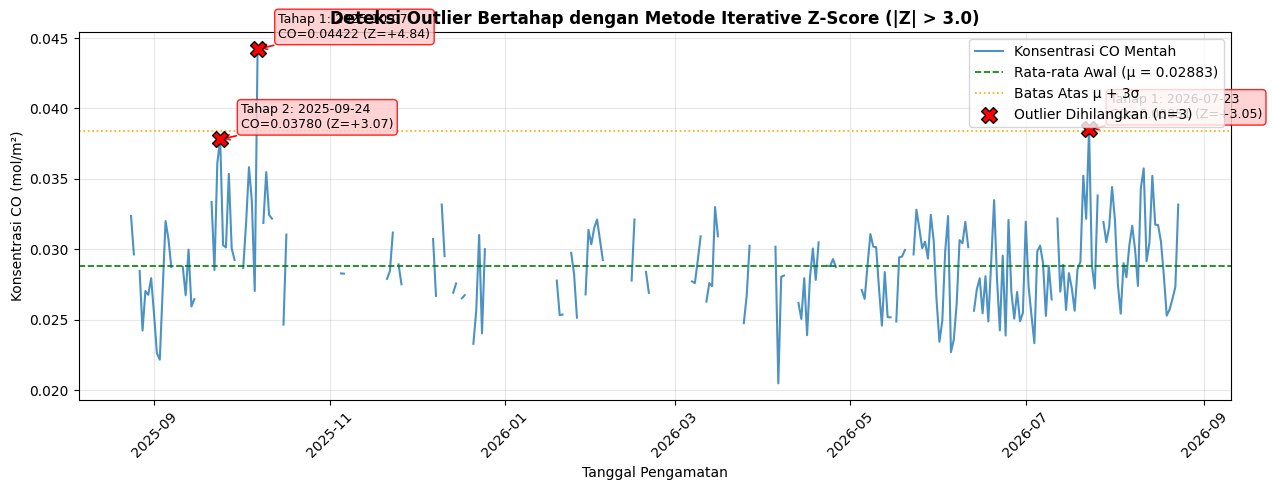

In [4]:
outlier_indices = [item['Index'] for item in all_outliers]
df_outliers_plot = df.loc[outlier_indices]

plt.figure(figsize=(13, 5))
plt.plot(df['tanggal'], df['CO'], color='#1f77b4', linewidth=1.5, label='Konsentrasi CO Mentah', alpha=0.8)
plt.axhline(mean_co, color='green', linestyle='--', linewidth=1.2, label=f'Rata-rata Awal (μ = {mean_co:.5f})')
plt.axhline(mean_co + 3 * std_co, color='orange', linestyle=':', linewidth=1.2, label='Batas Atas μ + 3σ')
plt.scatter(df_outliers_plot['tanggal'], df_outliers_plot['CO'], color='red', marker='X', s=130, edgecolor='black', zorder=5, label=f'Outlier Dihilangkan (n={len(df_outliers_plot)})')

for item in all_outliers:
    plt.annotate(f"{item['Tahap']}: {item['Tanggal']}\nCO={item['Nilai CO']:.5f} (Z={item['Z-Score']:+.2f})",
                 xy=(pd.to_datetime(item['Tanggal']), item['Nilai CO']), xytext=(15, 8), textcoords='offset points', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffcccc', edgecolor='red', alpha=0.85),
                 arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

plt.title('Deteksi Outlier Bertahap dengan Metode Iterative Z-Score (|Z| > 3.0)', fontsize=12, fontweight='bold')
plt.xlabel('Tanggal Pengamatan')
plt.ylabel('Konsentrasi CO (mol/m²)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Tahap 5: Penghilangan Outlier dan Ekspor Data Bersih

In [5]:
# 1. Data Bersih Utama: Outlier diubah menjadi NaN (struktur 365 hari lengkap)
df_clean = df[['tanggal', 'CO']].copy()
df_clean.loc[outlier_indices, 'CO'] = np.nan

# 2. Data Alternatif: Baris outlier dihapus secara fisik
df_dropped = df.drop(index=outlier_indices)[['tanggal', 'CO']].copy()

output_folder = "../data/csv/pertemuan-3-csv"
if not os.path.exists(output_folder) and os.path.exists("data/csv/pertemuan-3-csv"):
    output_folder = "data/csv/pertemuan-3-csv"
os.makedirs(output_folder, exist_ok=True)

clean_csv_path = os.path.join(output_folder, "polutan_co_bangkalan_clean.csv")
df_clean.to_csv(clean_csv_path, index=False)
print(f"✓ File data bersih utama berhasil disimpan di: {clean_csv_path}")

dropped_csv_path = os.path.join(output_folder, "polutan_co_bangkalan_no_outliers.csv")
df_dropped.to_csv(dropped_csv_path, index=False)
print(f"✓ File tanpa baris outlier berhasil disimpan di: {dropped_csv_path}")

# Verifikasi Z-Score pada data bersih
co_v = df_clean['CO'].dropna()
z_v = (co_v - co_v.mean()) / co_v.std()
outliers_sisa = co_v[z_v.abs() > THRESHOLD]
print(f"\n=== UJI VERIFIKASI Z-SCORE DATA BERSIH ===")
print(f"Total Baris Data        : {len(df_clean)} hari")
print(f"Data Valid              : {len(co_v)} hari")
print(f"Missing Values (NaN)    : {df_clean['CO'].isna().sum()} hari")
print(f"Jumlah Outlier Sisa     : {len(outliers_sisa)} titik (100% BEBAS OUTLIER)")


✓ File data bersih utama berhasil disimpan di: ../data/csv/pertemuan-3-csv\polutan_co_bangkalan_clean.csv
✓ File tanpa baris outlier berhasil disimpan di: ../data/csv/pertemuan-3-csv\polutan_co_bangkalan_no_outliers.csv

=== UJI VERIFIKASI Z-SCORE DATA BERSIH ===
Total Baris Data        : 365 hari
Data Valid              : 233 hari
Missing Values (NaN)    : 132 hari
Jumlah Outlier Sisa     : 0 titik (100% BEBAS OUTLIER)
